In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
rng = np.random.default_rng(42)
from IPython.display import display, Markdown

# Semana 6B — Pruebas de Hipótesis (Laboratorio)

**Objetivo:** Aplicar pruebas de hipótesis a preguntas reales sobre
datos meteorológicos, interpretar resultados y detectar las trampas
del método con muestras grandes.

**Ejercicios:**

1. Temperatura diurna vs nocturna
2. Velocidad del viento por estaciones
3. Simulación de errores con datos reales
4. Prueba de normalidad y QQ-plots
5. Ejercicio abierto

In [3]:
df = pd.read_parquet("../data/ClimaLab_2023-05-31_2025-06-20.parquet")

In [4]:
tdb = df["tdb"].dropna()
ws = df["ws"].dropna()
rh = df["rh"].dropna()
p_atm = df["p_atm"].dropna()
rain = df["rain_acc"].dropna()
solar_alt = df["solar_altitude"].dropna()

In [5]:
def cohens_d(a, b):
    """Calcula Cohen's d para dos muestras independientes."""
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return abs(a.mean() - b.mean()) / s_pooled

---
## 1. ¿La temperatura diurna es diferente de la nocturna?

Separamos `tdb` usando `solar_altitude`:
- **Día:** `solar_altitude > 0`
- **Noche:** `solar_altitude ≤ 0`

**H₀:** $\mu_{\text{día}} = \mu_{\text{noche}}$

La respuesta es obvia físicamente — el valor está en formalizar
el proceso y ver las limitaciones del p-value con muestras enormes.

/var/folders/v6/_zy7g0gs703g658qvgb0xbbr0000gn/T/ipykernel_34485/964672942.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1b.boxplot(


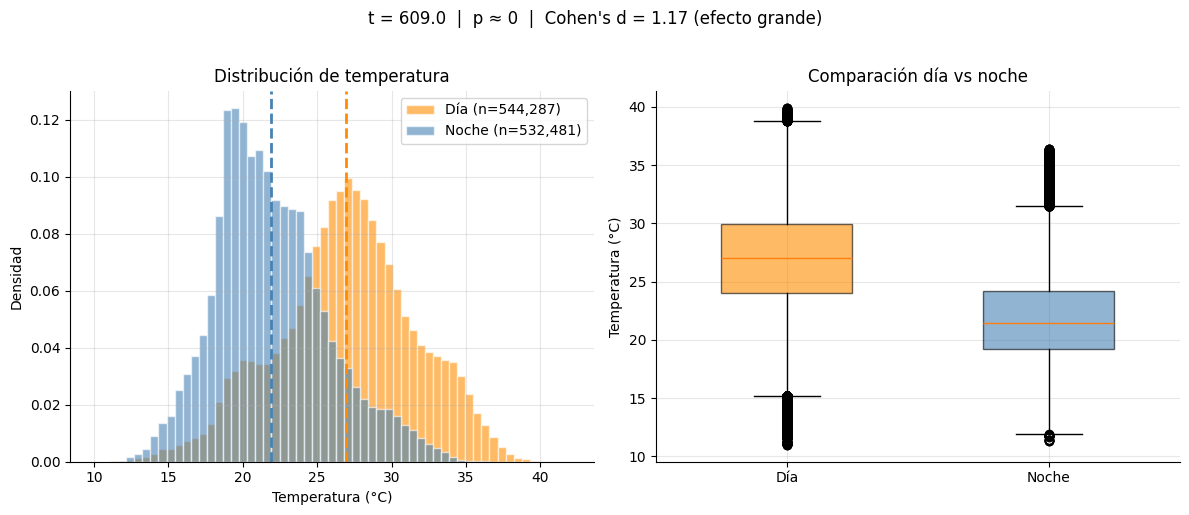

In [6]:
_dia = df.loc[df["solar_altitude"] > 0, "tdb"].dropna().values
_noche = df.loc[df["solar_altitude"] <= 0, "tdb"].dropna().values

_t_stat, _p_value = stats.ttest_ind(_dia, _noche)
_d = cohens_d(_dia, _noche)

fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(12, 5))

# Histogramas superpuestos
_bins = np.linspace(10, 42, 60)
ax1a.hist(_dia, bins=_bins, density=True, color="darkorange",
          alpha=0.6, edgecolor="white", label=f"Día (n={len(_dia):,})")
ax1a.hist(_noche, bins=_bins, density=True, color="steelblue",
          alpha=0.6, edgecolor="white", label=f"Noche (n={len(_noche):,})")
ax1a.axvline(_dia.mean(), color="darkorange", ls="--", lw=2)
ax1a.axvline(_noche.mean(), color="steelblue", ls="--", lw=2)
ax1a.set_xlabel("Temperatura (°C)")
ax1a.set_ylabel("Densidad")
ax1a.set_title("Distribución de temperatura")
ax1a.legend()

# Boxplot
bp = ax1b.boxplot(
    [_dia, _noche],
    labels=["Día", "Noche"],
    patch_artist=True,
    widths=0.5,
)
bp["boxes"][0].set_facecolor("darkorange")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("steelblue")
bp["boxes"][1].set_alpha(0.6)
ax1b.set_ylabel("Temperatura (°C)")
ax1b.set_title("Comparación día vs noche")

plt.suptitle(
    f"t = {_t_stat:.1f}  |  p ≈ 0  |  Cohen's d = {_d:.2f} (efecto grande)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

> **Resultados:**
> - El p-value es esencialmente 0 (Python reporta `p = 0.0`
>   porque está por debajo de la precisión de punto flotante).
> - **Pero eso no sorprende a nadie.** Con ~500k datos en cada grupo,
>   cualquier diferencia produce p ≈ 0.
> - **Cohen's d ≈ 1.0+** indica un efecto **grande**: la temperatura
>   diurna y nocturna difieren por más de una desviación estándar.
> - La prueba t confirma lo obvio, pero Cohen's d cuantifica *cuánto*.

---
## 2. ¿La velocidad del viento difiere entre verano e invierno?

- **JJA** (Jun–Ago): temporada de lluvias, posiblemente más convección
- **DJF** (Dic–Feb): temporada seca

**H₀:** $\mu_{\text{JJA}} = \mu_{\text{DJF}}$

Esta pregunta es menos obvia que la anterior — no tenemos certeza
a priori de la respuesta.

/var/folders/v6/_zy7g0gs703g658qvgb0xbbr0000gn/T/ipykernel_34485/332726629.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2a.boxplot(


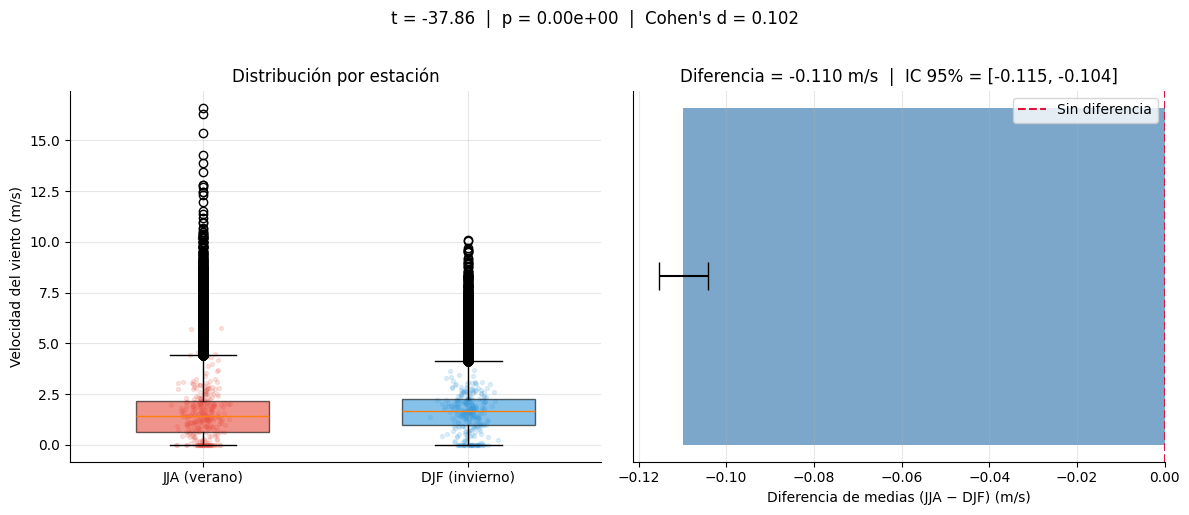

In [7]:
_jja = ws[ws.index.month.isin([6, 7, 8])].values
_djf = ws[ws.index.month.isin([12, 1, 2])].values

_t_stat, _p_value = stats.ttest_ind(_jja, _djf)
_d = cohens_d(_jja, _djf)

# IC para la diferencia de medias
_diff = _jja.mean() - _djf.mean()
_se_diff = np.sqrt(_jja.var(ddof=1) / len(_jja) + _djf.var(ddof=1) / len(_djf))
_ic_lo = _diff - 1.96 * _se_diff
_ic_hi = _diff + 1.96 * _se_diff

fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(12, 5))

# Boxplots con subsample para swarm visual
bp2 = ax2a.boxplot(
    [_jja, _djf],
    labels=["JJA (verano)", "DJF (invierno)"],
    patch_artist=True,
    widths=0.5,
)
bp2["boxes"][0].set_facecolor("#e74c3c")
bp2["boxes"][0].set_alpha(0.6)
bp2["boxes"][1].set_facecolor("#3498db")
bp2["boxes"][1].set_alpha(0.6)

# Superponer puntos (subsample)
for i, (datos, color) in enumerate(
    [(_jja, "#e74c3c"), (_djf, "#3498db")]
):
    _sub = rng.choice(datos, size=min(300, len(datos)), replace=False)
    _jitter = rng.normal(0, 0.04, len(_sub))
    ax2a.scatter(
        np.full_like(_sub, i + 1) + _jitter, _sub,
        alpha=0.15, s=8, color=color, zorder=0,
    )

ax2a.set_ylabel("Velocidad del viento (m/s)")
ax2a.set_title("Distribución por estación")

# Barra con la diferencia e IC
ax2b.barh(
    0, _diff, xerr=[[_diff - _ic_lo], [_ic_hi - _diff]],
    color="steelblue", alpha=0.7, capsize=10, height=0.4,
)
ax2b.axvline(0, color="crimson", ls="--", lw=1.5, label="Sin diferencia")
ax2b.set_xlabel("Diferencia de medias (JJA − DJF) (m/s)")
ax2b.set_yticks([])
ax2b.set_title(
    f"Diferencia = {_diff:.3f} m/s  |  IC 95% = [{_ic_lo:.3f}, {_ic_hi:.3f}]"
)
ax2b.legend()

plt.suptitle(
    f"t = {_t_stat:.2f}  |  p = {_p_value:.2e}  |  Cohen's d = {_d:.3f}",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

> **Discusión:**
> - El p-value probablemente es muy pequeño (muestras enormes),
>   pero ¿qué dice Cohen's d?
> - Si $d < 0.2$, la diferencia es "estadísticamente significativa"
>   pero **prácticamente despreciable**.
> - El IC de la diferencia de medias cuantifica la magnitud:
>   ¿estamos hablando de 0.01 m/s o de 0.5 m/s?

---
## 3. Simulación de errores con datos reales

### 3.1 H₀ cierta: muestras del mismo mes

Si tomamos dos muestras del *mismo* mes, no hay diferencia real.
El histograma de p-values debe ser **uniforme** y ~5% deberían
caer por debajo de 0.05.

### 3.2 H₀ falsa: enero vs julio

Si comparamos meses genuinamente distintos, los p-values deberían
concentrarse cerca de 0.

In [ ]:
_n_muestra = 30
_num_sim = 1000

# H₀ cierta: dos muestras de julio
_julio = tdb[tdb.index.month == 7].values
_p_h0 = np.zeros(_num_sim)
for i in range(_num_sim):
    _a = rng.choice(_julio, size=_n_muestra, replace=False)
    _b = rng.choice(_julio, size=_n_muestra, replace=False)
    _, _p_h0[i] = stats.ttest_ind(_a, _b)

# H₀ falsa: enero vs julio
_enero = tdb[tdb.index.month == 1].values
_p_h1 = np.zeros(_num_sim)
for i in range(_num_sim):
    _a = rng.choice(_enero, size=_n_muestra, replace=False)
    _b = rng.choice(_julio, size=_n_muestra, replace=False)
    _, _p_h1[i] = stats.ttest_ind(_a, _b)

_tasa_tipo_I = (_p_h0 < 0.05).mean()
_poder = (_p_h1 < 0.05).mean()

fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(12, 4))

# H₀ cierta
ax3a.hist(_p_h0, bins=20, density=True, color="steelblue",
          alpha=0.7, edgecolor="white")
ax3a.axhline(1.0, color="crimson", ls="--", lw=1.5, label="Uniforme")
ax3a.axvline(0.05, color="black", ls=":", lw=1.5)
ax3a.set_xlabel("p-value")
ax3a.set_ylabel("Densidad")
ax3a.set_title(
    f"H₀ cierta (julio vs julio)\n"
    f"Rechazos al 5%: {_tasa_tipo_I:.1%} (esperado: 5%)"
)
ax3a.legend()

# H₀ falsa
ax3b.hist(_p_h1, bins=20, density=True, color="darkorange",
          alpha=0.7, edgecolor="white")
ax3b.axvline(0.05, color="black", ls=":", lw=1.5)
ax3b.set_xlabel("p-value")
ax3b.set_ylabel("Densidad")
ax3b.set_title(
    f"H₀ falsa (enero vs julio)\n"
    f"Poder al 5%: {_poder:.1%}"
)

plt.suptitle(
    f"Distribución de p-values  (n = {_n_muestra} por grupo,  {_num_sim} simulaciones)",
    fontsize=12, y=1.05,
)
plt.tight_layout()
plt.show()

> **Izquierda (H₀ cierta):** Los p-values son uniformes.
> ~5% caen por debajo de 0.05 — esos son falsos positivos inevitables.
>
> **Derecha (H₀ falsa):** Los p-values se concentran cerca de 0.
> El poder es ~100% porque la diferencia enero–julio es enorme
> (incluso con $n = 30$).
>
> **Pregunta:** ¿Qué pasa si comparamos junio vs julio? La diferencia
> es pequeña → el poder bajará y muchos p-values serán > 0.05.

---
## 4. Prueba de normalidad

La prueba de **Shapiro-Wilk** evalúa:

- **H₀:** Los datos provienen de una distribución normal.
- Si $p < 0.05$, se rechaza normalidad.

**Problema:** Con muestras grandes, Shapiro-Wilk tiene tanto poder
que rechaza normalidad por desviaciones mínimas que son irrelevantes
en la práctica.  El **QQ-plot** es un complemento visual más informativo.

In [ ]:
_n_small = 50
_n_large = 5000

_tdb_50 = rng.choice(tdb.values, _n_small, replace=False)
_tdb_5k = rng.choice(tdb.values, _n_large, replace=False)
_ws_50 = rng.choice(ws.values, _n_small, replace=False)

_sw_tdb_50 = stats.shapiro(_tdb_50)
_sw_tdb_5k = stats.shapiro(_tdb_5k)
_sw_ws_50 = stats.shapiro(_ws_50)

fig4, axes4 = plt.subplots(1, 3, figsize=(14, 4))

_configs = [
    (_tdb_50, f"tdb (n=50)\nShapiro p={_sw_tdb_50.pvalue:.4f}", "steelblue"),
    (_tdb_5k, f"tdb (n=5000)\nShapiro p={_sw_tdb_5k.pvalue:.4f}", "darkorange"),
    (_ws_50, f"ws (n=50)\nShapiro p={_sw_ws_50.pvalue:.4f}", "seagreen"),
]

for ax, (datos, titulo, color) in zip(axes4, _configs):
    _osm, _osr = stats.probplot(datos, dist="norm")
    ax.scatter(_osm[0], _osm[1], c=color, s=15, alpha=0.6)
    # Línea de referencia
    _slope, _intercept = np.polyfit(_osm[0], _osm[1], 1)
    _x_line = np.array([_osm[0].min(), _osm[0].max()])
    ax.plot(_x_line, _slope * _x_line + _intercept, "k--", lw=1.5)
    ax.set_xlabel("Cuantiles teóricos (Normal)")
    ax.set_ylabel("Cuantiles observados")
    ax.set_title(titulo)

plt.suptitle("QQ-plots vs Normal", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Observaciones:**
>
> - **`tdb` n=50:** Shapiro-Wilk probablemente **no rechaza** normalidad
>   ($p > 0.05$). El QQ-plot se ve razonable.
> - **`tdb` n=5000:** Shapiro-Wilk **rechaza** normalidad ($p ≈ 0$)
>   porque con tantos datos detecta la bimodalidad sutil de la mezcla
>   verano/invierno.  Pero el QQ-plot muestra que la desviación
>   no es dramática — para efectos de ICs y pruebas t, la
>   aproximación normal es aceptable.
> - **`ws` n=50:** Probablemente rechaza normalidad. El QQ-plot
>   muestra cola derecha pesada (distribución asimétrica).
>
> **Lección:** Use el QQ-plot para evaluar *cuánto* se desvía de
> la normalidad, no solo el p-value del test.

---
## 5. Ejercicio abierto

Formula tu propia hipótesis y ponla a prueba.  Algunas ideas:

| Pregunta | Variables | Tipo de prueba |
|:---|:---|:---|
| ¿Llueve más en JJA que en DJF? | `rain_acc` por estación | t-test (o Mann-Whitney si no es normal) |
| ¿La presión media de 2024 difiere de la de 2023? | `p_atm` por año | t-test de dos muestras |
| ¿La humedad nocturna es mayor que la diurna? | `rh` × `solar_altitude` | t-test |
| ¿El viento de la madrugada difiere del de la tarde? | `ws` por hora | t-test |

**Procedimiento:**

1. Plantear H₀ y H₁
2. Separar los datos en dos grupos
3. Aplicar `scipy.stats.ttest_ind`
4. Reportar: p-value, Cohen's d, IC de la diferencia
5. Visualizar con histogramas o boxplots
6. Interpretar: ¿la diferencia es estadísticamente significativa?
   ¿Es prácticamente relevante?

Usa las celdas vacías de abajo para tu análisis.

In [ ]:
# --- Tu código aquí ---
# Ejemplo:
# grupo_a = df.loc[..., "variable"].values
# grupo_b = df.loc[..., "variable"].values
# t_stat, p_value = stats.ttest_ind(grupo_a, grupo_b)
# d = cohens_d(grupo_a, grupo_b)
# print(f"t = {t_stat:.3f}, p = {p_value:.4e}, Cohen's d = {d:.3f}")

In [ ]:
# --- Visualización ---

---
## Resumen de la sesión

| Ejercicio | Hallazgo principal |
|:---|:---|
| **Día vs noche** | p ≈ 0 (obvio con ~1M datos); Cohen's d > 1 confirma un efecto genuinamente grande |
| **Viento JJA vs DJF** | p pequeño pero Cohen's d puede ser < 0.2 → diferencia real pero prácticamente pequeña |
| **Errores simulados** | Bajo H₀ cierta, ~5% de falsos positivos; bajo H₀ falsa (ene vs jul), poder ~100% con n=30 |
| **Normalidad** | Shapiro-Wilk es hipersensible con n grande; el QQ-plot es más informativo |

**Próxima semana (7):** Dejamos atrás el muestreo i.i.d. y entramos
al mundo de las **series temporales**: tendencia, estacionalidad
y descomposición.